In [1]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score, roc_curve, auc, precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Load the CICIDS 2017 dataset
# Load your dataset
# Note: Adjust the file path to where your dataset is located
data = pd.read_csv('cicids2017_cleaned.csv')

# For this example, we're assuming that the last column is the label for binary classification
# and the rest are features
X = data.iloc[:, :-1]  # Features
y = data.iloc[:, -1]   # Target variable

# Step 2: Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 3: Train the XGBoost model
# Convert the data to DMatrix format (specific to XGBoost)
dtrain = xgb.DMatrix(X_train, label=y_train)
dtest = xgb.DMatrix(X_test, label=y_test)

# Set up XGBoost parameters
params = {
    'objective': 'binary:logistic',  # Binary classification
    'eval_metric': 'logloss',
    'max_depth': 6,  # Tree depth
    'eta': 0.3,      # Learning rate
    'subsample': 0.8,  # Sampling ratio
    'colsample_bytree': 0.8,  # Feature sampling
}

# Train the model
bst = xgb.train(params, dtrain, num_boost_round=100)

# Step 4: Make predictions
y_pred_prob = bst.predict(dtest)  # Predicted probabilities
y_pred = np.round(y_pred_prob)  # Convert probabilities to binary output (0 or 1)

# Step 5: Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Print evaluation metrics
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"Confusion Matrix:\n{conf_matrix}")

# Step 6: Plot the confusion matrix
plt.figure(figsize=(6, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False, xticklabels=['Normal', 'Attack'], yticklabels=['Normal', 'Attack'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# Step 7: Plot the ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc='lower right')
plt.show()

# Step 8: Plot the Precision-Recall curve
precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_pred_prob)
average_precision = average_precision_score(y_test, y_pred_prob)

plt.figure(figsize=(8, 6))
plt.plot(recall_vals, precision_vals, color='blue', lw=2, label=f'Precision-Recall curve (AP = {average_precision:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc='lower left')
plt.show()


ValueError: could not convert string to float: 'Normal Traffic'

In [3]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score, roc_curve, auc, precision_recall_curve, average_precision_score
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Load the CICIDS 2017 dataset
data = pd.read_csv('cicids2017_cleaned.csv')

# Step 2: Encode the target variable if it's a string (e.g., 'Normal Traffic', 'Attack')
# Assuming the last column is the target
label_encoder = LabelEncoder()
data['Attack Type'] = label_encoder.fit_transform(data['Attack Type'])  # Replace 'Label' with the correct target column name

# Separate the features (X) and target (y)
X = data.iloc[:, :-1]  # All columns except the last one (target)
y = data.iloc[:, -1]   # The last column (target)

# Step 3: Handle categorical columns in features (if any)
# For simplicity, let's assume that categorical features should be one-hot encoded
# One-hot encoding for categorical variables (if any categorical column exists in X)
X = pd.get_dummies(X)

# Step 4: Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 5: Train the XGBoost model
dtrain = xgb.DMatrix(X_train, label=y_train)
dtest = xgb.DMatrix(X_test, label=y_test)

# Set up XGBoost parameters
params = {
    'objective': 'binary:logistic',  # Binary classification
    'eval_metric': 'logloss',
    'max_depth': 6,  # Tree depth
    'eta': 0.3,      # Learning rate
    'subsample': 0.8,  # Sampling ratio
    'colsample_bytree': 0.8,  # Feature sampling
}

# Train the model
bst = xgb.train(params, dtrain, num_boost_round=100)

# Step 6: Make predictions
y_pred_prob = bst.predict(dtest)  # Predicted probabilities
y_pred = np.round(y_pred_prob)  # Convert probabilities to binary output (0 or 1)

# Step 7: Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Print evaluation metrics
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"Confusion Matrix:\n{conf_matrix}")

# Step 8: Plot the confusion matrix
plt.figure(figsize=(6, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False, xticklabels=['Normal', 'Attack'], yticklabels=['Normal', 'Attack'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# Step 9: Plot the ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc='lower right')
plt.show()

# Step 10: Plot the Precision-Recall curve
precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_pred_prob)
average_precision = average_precision_score(y_test, y_pred_prob)

plt.figure(figsize=(8, 6))
plt.plot(recall_vals, precision_vals, color='blue', lw=2, label=f'Precision-Recall curve (AP = {average_precision:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc='lower left')
plt.show()


XGBoostError: [14:58:51] C:\actions-runner\_work\xgboost\xgboost\src\objective\./regression_loss.h:69: Check failed: base_score > 0.0f && base_score < 1.0f: base_score must be in (0,1) for logistic loss, got: 3.84534

In [5]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score, roc_curve, auc, precision_recall_curve, average_precision_score
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Load the CICIDS 2017 dataset
data = pd.read_csv('cicids2017_cleaned.csv')

# Step 2: Encode the target variable if it's a string (e.g., 'Normal Traffic', 'Attack')
# Assuming the last column is the target
label_encoder = LabelEncoder()
data['Attack Type'] = label_encoder.fit_transform(data['Attack Type'])  # Replace 'Label' with the correct target column name

# Separate the features (X) and target (y)
X = data.iloc[:, :-1]  # All columns except the last one (target)
y = data.iloc[:, -1]   # The last column (target)

# Step 3: Handle categorical columns in features (if any)
# For simplicity, let's assume that categorical features should be one-hot encoded
# One-hot encoding for categorical variables (if any categorical column exists in X)
X = pd.get_dummies(X)

# Step 4: Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 5: Train the XGBoost model
dtrain = xgb.DMatrix(X_train, label=y_train)
dtest = xgb.DMatrix(X_test, label=y_test)

# Set up XGBoost parameters
params = {
    'objective': 'binary:logistic',  # Binary classification
    'eval_metric': 'logloss',
    'max_depth': 6,  # Tree depth
    'eta': 0.3,      # Learning rate
    'subsample': 0.8,  # Sampling ratio
    'colsample_bytree': 0.8,  # Feature sampling
    'base_score': 0.5  # Set base_score to 0.5 for binary classification
}

# Train the model
bst = xgb.train(params, dtrain, num_boost_round=100)

# Step 6: Make predictions
y_pred_prob = bst.predict(dtest)  # Predicted probabilities
y_pred = np.round(y_pred_prob)  # Convert probabilities to binary output (0 or 1)

# Step 7: Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Print evaluation metrics
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"Confusion Matrix:\n{conf_matrix}")

# Step 8: Plot the confusion matrix
plt.figure(figsize=(6, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False, xticklabels=['Normal', 'Attack'], yticklabels=['Normal', 'Attack'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# Step 9: Plot the ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc='lower right')
plt.show()

# Step 10: Plot the Precision-Recall curve
precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_pred_prob)
average_precision = average_precision_score(y_test, y_pred_prob)

plt.figure(figsize=(8, 6))
plt.plot(recall_vals, precision_vals, color='blue', lw=2, label=f'Precision-Recall curve (AP = {average_precision:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc='lower left')
plt.show()


XGBoostError: [15:01:28] C:\actions-runner\_work\xgboost\xgboost\src\objective\regression_obj.cu:101: label must be in [0,1] for logistic regression

In [8]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score, roc_curve, auc, precision_recall_curve, average_precision_score
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Load the CICIDS 2017 dataset
data = pd.read_csv('cicids2017_cleaned.csv')

# Step 2: Encode the target variable if it's a string (e.g., 'Normal Traffic', 'Attack')
# Assuming the last column is the target column
label_encoder = LabelEncoder()
# Ensure that the target is binary (e.g., 'Normal Traffic' -> 0, 'Attack' -> 1)
data['Attack Type'] = label_encoder.fit_transform(data['Attack Type'])  # Replace 'Label' with the correct target column name

# Check unique values in the 'Label' column
print("Unique target values after encoding:", data['Attack Type'].unique())

# Separate the features (X) and target (y)
X = data.iloc[:, :-1]  # All columns except the last one (target)
y = data.iloc[:, -1]   # The last column (target)

# Step 3: Handle categorical columns in features (if any)
# For simplicity, let's assume that categorical features should be one-hot encoded
# One-hot encoding for categorical variables (if any categorical column exists in X)
X = pd.get_dummies(X)

# Step 4: Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 5: Train the XGBoost model
dtrain = xgb.DMatrix(X_train, label=y_train)
dtest = xgb.DMatrix(X_test, label=y_test)

# Set up XGBoost parameters
params = {
    'objective': 'binary:logistic',  # Binary classification
    'eval_metric': 'logloss',
    'max_depth': 6,  # Tree depth
    'eta': 0.3,      # Learning rate
    'subsample': 0.8,  # Sampling ratio
    'colsample_bytree': 0.8,  # Feature sampling
    'base_score': 0.5  # Set base_score to 0.5 for binary classification
}

# Train the model
bst = xgb.train(params, dtrain, num_boost_round=100)

# Step 6: Make predictions
y_pred_prob = bst.predict(dtest)  # Predicted probabilities
y_pred = np.round(y_pred_prob)  # Convert probabilities to binary output (0 or 1)

# Step 7: Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Print evaluation metrics
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"Confusion Matrix:\n{conf_matrix}")

# Step 8: Plot the confusion matrix
plt.figure(figsize=(6, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False, xticklabels=['Normal', 'Attack'], yticklabels=['Normal', 'Attack'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# Step 9: Plot the ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc='lower right')
plt.show()

# Step 10: Plot the Precision-Recall curve
precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_pred_prob)
average_precision = average_precision_score(y_test, y_pred_prob)

plt.figure(figsize=(8, 6))
plt.plot(recall_vals, precision_vals, color='blue', lw=2, label=f'Precision-Recall curve (AP = {average_precision:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc='lower left')
plt.show()


Unique target values after encoding: [4 5 6 1 2 0 3]


XGBoostError: [15:03:48] C:\actions-runner\_work\xgboost\xgboost\src\objective\regression_obj.cu:101: label must be in [0,1] for logistic regression

In [9]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score, roc_curve, auc, precision_recall_curve, average_precision_score
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Load the CICIDS 2017 dataset
data = pd.read_csv('cicids2017_cleaned.csv')

# Step 2: Check unique values in the 'Label' column before encoding
print("Unique values in 'Attack Type' before encoding:", data['Attack Type'].unique())

# Encode the target variable if it's a string (e.g., 'Normal Traffic', 'Attack')
# Assuming 'Label' is the target column
label_encoder = LabelEncoder()

# Assuming 'Label' column contains 'Normal Traffic' and 'Attack' as string values
# We convert them to binary: 0 for 'Normal Traffic', 1 for 'Attack'
data['Attack Type'] = label_encoder.fit_transform(data['Attack Type'])

# Step 3: Check unique values in the 'Label' column after encoding
print("Unique values in 'Attack Type' after encoding:", data['Attack Type'].unique())

# Separate the features (X) and target (y)
X = data.iloc[:, :-1]  # All columns except the last one (target)
y = data.iloc[:, -1]   # The last column (target)

# Check the shape and the unique values in the target variable
print(f"Shape of data: {data.shape}")
print(f"Shape of features (X): {X.shape}")
print(f"Shape of target (y): {y.shape}")
print(f"Unique values in target (y): {np.unique(y)}")

# Step 4: Handle categorical columns in features (if any)
# For simplicity, let's assume that categorical features should be one-hot encoded
# One-hot encoding for categorical variables (if any categorical column exists in X)
X = pd.get_dummies(X)

# Step 5: Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 6: Train the XGBoost model
dtrain = xgb.DMatrix(X_train, label=y_train)
dtest = xgb.DMatrix(X_test, label=y_test)

# Set up XGBoost parameters
params = {
    'objective': 'binary:logistic',  # Binary classification
    'eval_metric': 'logloss',
    'max_depth': 6,  # Tree depth
    'eta': 0.3,      # Learning rate
    'subsample': 0.8,  # Sampling ratio
    'colsample_bytree': 0.8,  # Feature sampling
    'base_score': 0.5  # Set base_score to 0.5 for binary classification
}

# Train the model
bst = xgb.train(params, dtrain, num_boost_round=100)

# Step 7: Make predictions
y_pred_prob = bst.predict(dtest)  # Predicted probabilities
y_pred = np.round(y_pred_prob)  # Convert probabilities to binary output (0 or 1)

# Step 8: Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Print evaluation metrics
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"Confusion Matrix:\n{conf_matrix}")

# Step 9: Plot the confusion matrix
plt.figure(figsize=(6, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False, xticklabels=['Normal', 'Attack'], yticklabels=['Normal', 'Attack'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# Step 10: Plot the ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc='lower right')
plt.show()

# Step 11: Plot the Precision-Recall curve
precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_pred_prob)
average_precision = average_precision_score(y_test, y_pred_prob)

plt.figure(figsize=(8, 6))
plt.plot(recall_vals, precision_vals, color='blue', lw=2, label=f'Precision-Recall curve (AP = {average_precision:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc='lower left')
plt.show()


Unique values in 'Attack Type' before encoding: ['Normal Traffic' 'Port Scanning' 'Web Attacks' 'Brute Force' 'DDoS'
 'Bots' 'DoS']
Unique values in 'Attack Type' after encoding: [4 5 6 1 2 0 3]
Shape of data: (2520751, 53)
Shape of features (X): (2520751, 52)
Shape of target (y): (2520751,)
Unique values in target (y): [0 1 2 3 4 5 6]


XGBoostError: [15:07:33] C:\actions-runner\_work\xgboost\xgboost\src\objective\regression_obj.cu:101: label must be in [0,1] for logistic regression

In [ ]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score, roc_curve, auc, precision_recall_curve, average_precision_score
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Load the CICIDS 2017 dataset
data = pd.read_csv('cicids2017_cleaned.csv')

# Step 2: Check unique values in the 'Label' column before encoding
print("Unique values in 'Attack Type' before encoding:", data['Attack Type'].unique())

# Encode the target variable if it's a string (e.g., 'Normal Traffic', 'Attack')
# Assuming 'Label' is the target column
label_encoder = LabelEncoder()

# Assuming 'Label' column contains 'Normal Traffic' and 'Attack' as string values
# We convert them to binary: 0 for 'Normal Traffic', 1 for 'Attack'
data['Attack Type'] = label_encoder.fit_transform(data['Attack Type'])

# Step 3: Check unique values in the 'Label' column after encoding
print("Unique values in 'Attack Type' after encoding:", data['Attack Type'].unique())

# Ensure the labels are either 0 or 1
if not np.all(np.isin(data['Attack Type'], [0, 1])):
    print("Error: Target labels contain values other than 0 and 1!")
    print("Unique values in the target label after encoding:", np.unique(data['Attack Type']))
    exit()

# Separate the features (X) and target (y)
X = data.iloc[:, :-1]  # All columns except the last one (target)
y = data.iloc[:, -1]   # The last column (target)

# Check the shape and the unique values in the target variable
print(f"Shape of data: {data.shape}")
print(f"Shape of features (X): {X.shape}")
print(f"Shape of target (y): {y.shape}")
print(f"Unique values in target (y): {np.unique(y)}")

# Step 4: Handle categorical columns in features (if any)
# For simplicity, let's assume that categorical features should be one-hot encoded
# One-hot encoding for categorical variables (if any categorical column exists in X)
X = pd.get_dummies(X)

# Step 5: Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 6: Train the XGBoost model
dtrain = xgb.DMatrix(X_train, label=y_train)
dtest = xgb.DMatrix(X_test, label=y_test)

# Set up XGBoost parameters
params = {
    'objective': 'binary:logistic',  # Binary classification
    'eval_metric': 'logloss',
    'max_depth': 6,  # Tree depth
    'eta': 0.3,      # Learning rate
    'subsample': 0.8,  # Sampling ratio
    'colsample_bytree': 0.8,  # Feature sampling
    'base_score': 0.5  # Set base_score to 0.5 for binary classification
}

# Train the model
bst = xgb.train(params, dtrain, num_boost_round=100)

# Step 7: Make predictions
y_pred_prob = bst.predict(dtest)  # Predicted probabilities
y_pred = np.round(y_pred_prob)  # Convert probabilities to binary output (0 or 1)

# Step 8: Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Print evaluation metrics
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"Confusion Matrix:\n{conf_matrix}")

# Step 9: Plot the confusion matrix
plt.figure(figsize=(6, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False, xticklabels=['Normal', 'Attack'], yticklabels=['Normal', 'Attack'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# Step 10: Plot the ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc='lower right')
plt.show()

# Step 11: Plot the Precision-Recall curve
precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_pred_prob)
average_precision = average_precision_score(y_test, y_pred_prob)

plt.figure(figsize=(8, 6))
plt.plot(recall_vals, precision_vals, color='blue', lw=2, label=f'Precision-Recall curve (AP = {average_precision:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc='lower left')
plt.show()


Unique values in 'Attack Type' before encoding: ['Normal Traffic' 'Port Scanning' 'Web Attacks' 'Brute Force' 'DDoS'
 'Bots' 'DoS']
Unique values in 'Attack Type' after encoding: [4 5 6 1 2 0 3]
Error: Target labels contain values other than 0 and 1!
Unique values in the target label after encoding: [0 1 2 3 4 5 6]
Shape of data: (2520751, 53)
Shape of features (X): (2520751, 52)
Shape of target (y): (2520751,)
Unique values in target (y): [0 1 2 3 4 5 6]


XGBoostError: [15:11:18] C:\actions-runner\_work\xgboost\xgboost\src\objective\regression_obj.cu:101: label must be in [0,1] for logistic regression

: 

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score, roc_curve, auc, precision_recall_curve
import matplotlib.pyplot as plt
from xgboost import XGBClassifier

# Load the dataset (replace 'path_to_dataset.csv' with the actual path to your CICIDS 2017 dataset)
data = pd.read_csv('cicids2017_cleaned.csv')

# Preprocess the data (adjust column names and preprocessing as per your dataset)
X = data.drop('Attack Type', axis=1)  # Features
y = data['Attack Type']  # Target (binary labels: 0 or 1)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# Initialize and train the XGBoost classifier
model = XGBClassifier(objective='binary:logistic', random_state=42)
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy: {accuracy}")
print(f"Confusion Matrix:\n{conf_matrix}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1 Score: {f1}")

# Plot confusion matrix
plt.figure(figsize=(6, 6))
plt.imshow(conf_matrix, cmap='Blues', interpolation='nearest')
plt.title('Confusion Matrix')
plt.colorbar()
plt.xticks([0, 1], ['Class 0', 'Class 1'])
plt.yticks([0, 1], ['Class 0', 'Class 1'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Plot ROC curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')  # Diagonal line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()

# Plot Precision-Recall curve
precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_pred_proba)

plt.figure(figsize=(6, 6))
plt.plot(recall_vals, precision_vals, label='Precision-Recall Curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc='lower right')
plt.show()


ValueError: Invalid classes inferred from unique values of `y`.  Expected: [0 1 2 3 4 5 6], got ['Bots' 'Brute Force' 'DDoS' 'DoS' 'Normal Traffic' 'Port Scanning'
 'Web Attacks']

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score, roc_curve, auc, precision_recall_curve
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
from xgboost import XGBClassifier

# Load the dataset (replace 'path_to_dataset.csv' with the actual path to your CICIDS 2017 dataset)
data = pd.read_csv('D:\datasets\cicids 2017 cleaned and preprocessed\cicids2017_cleaned.csv')

# Preprocess the data (adjust column names and preprocessing as per your dataset)
X = data.drop('Attack Type', axis=1)  # Features
y = data['Attack Type']  # Target (string labels)

# Encode string labels into integers
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.25, random_state=42)

# Initialize and train the XGBoost classifier
model = XGBClassifier(objective='binary:logistic', random_state=42)
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy: {accuracy}")
print(f"Confusion Matrix:\n{conf_matrix}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1 Score: {f1}")

# Plot confusion matrix
plt.figure(figsize=(6, 6))
plt.imshow(conf_matrix, cmap='Blues', interpolation='nearest')
plt.title('Confusion Matrix')
plt.colorbar()
plt.xticks([0, 1], ['Class 0', 'Class 1'])
plt.yticks([0, 1], ['Class 0', 'Class 1'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Plot ROC curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')  # Diagonal line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()

# Plot Precision-Recall curve
precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_pred_proba)

plt.figure(figsize=(6, 6))
plt.plot(recall_vals, precision_vals, label='Precision-Recall Curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc='lower right')
plt.show()


ValueError: Target is multiclass but average='binary'. Please choose another average setting, one of [None, 'micro', 'macro', 'weighted'].

Accuracy: 0.9991399391927488
Confusion Matrix:
[[   361      0      0      0    122      0      0]
 [     0   2300      0      0      1      0      0]
 [     0      0  32109      0      6      0      0]
 [     0      0      0  48612     14      2      3]
 [    31      0      3     68 522894    263      3]
 [     0      0      0      8      4  22830      1]
 [     0      0      0      1     12      0    540]]
Precision: 0.9849525819637509
Recall: 0.9602313383730479
F1 Score: 0.9712945461713319


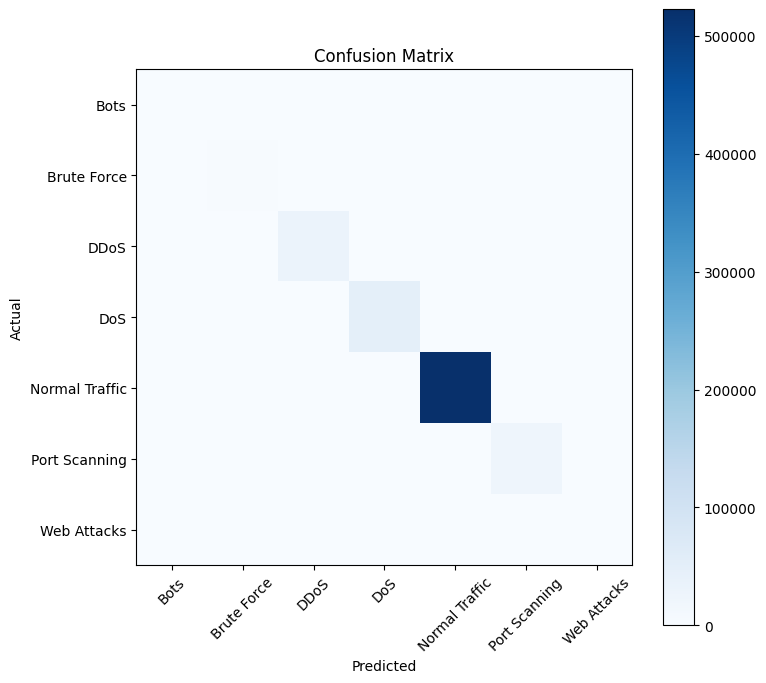

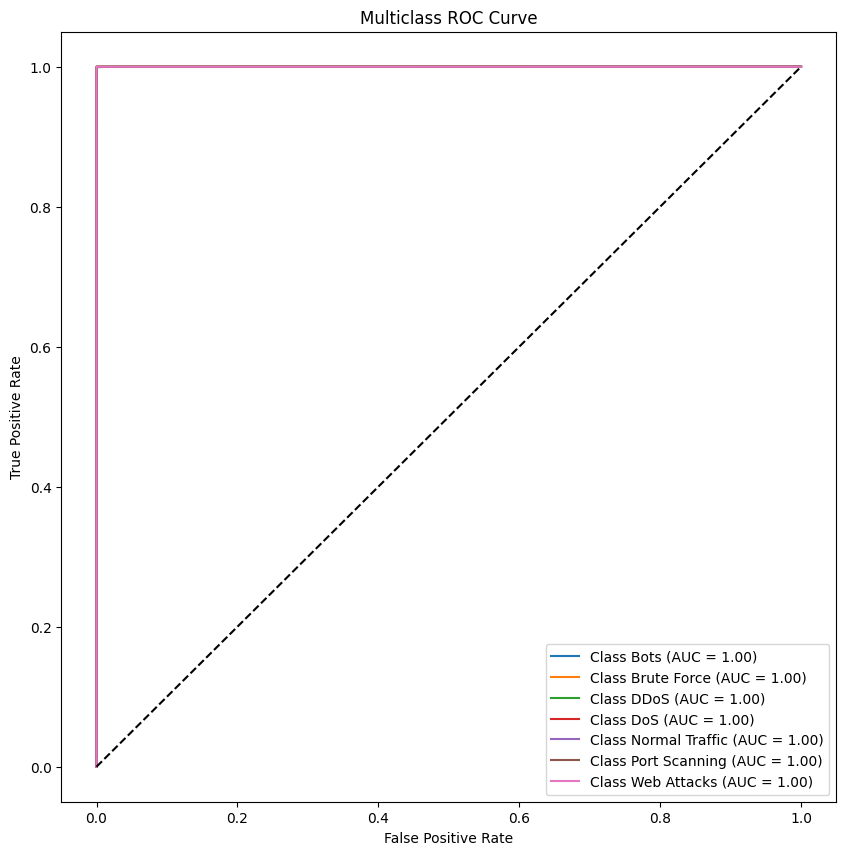

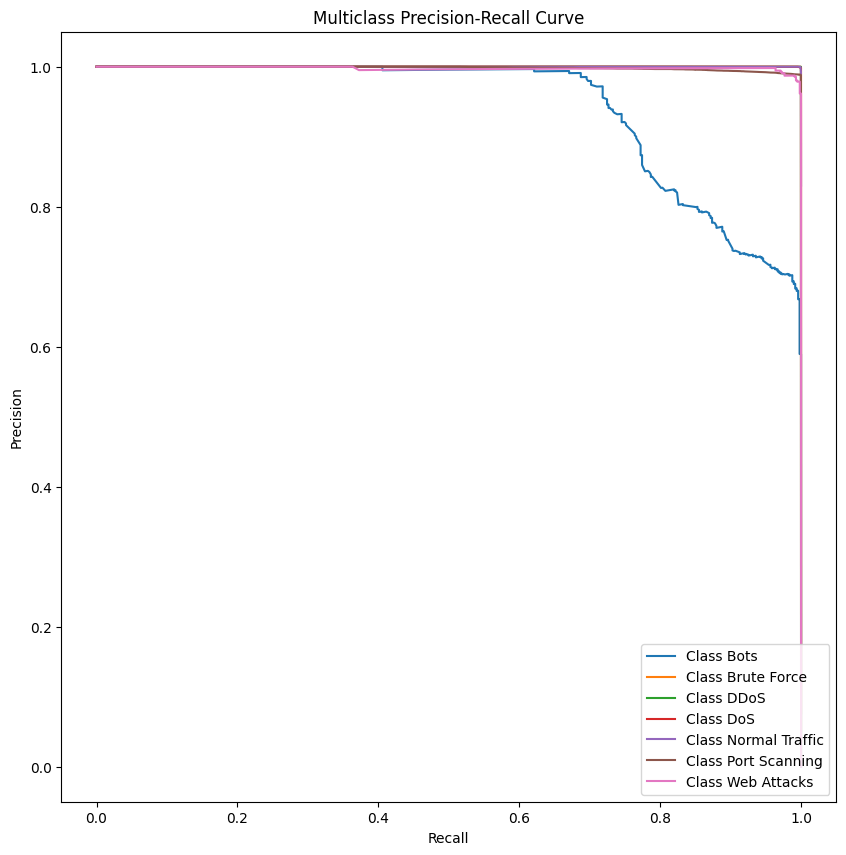

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score, roc_curve, auc, precision_recall_curve
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
from xgboost import XGBClassifier

# Load the dataset (replace 'path_to_dataset.csv' with the actual path to your CICIDS 2017 dataset)
data = pd.read_csv('D:\datasets\cicids 2017 cleaned and preprocessed\cicids2017_cleaned.csv')

# Preprocess the data (adjust column names and preprocessing as per your dataset)
X = data.drop('Attack Type', axis=1)  # Features
y = data['Attack Type']  # Target (string labels)

# Encode string labels into integers
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Get the number of unique classes
num_classes = len(np.unique(y_encoded))

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.25, random_state=42)

# Initialize and train the XGBoost classifier for multiclass classification
model = XGBClassifier(objective='multi:softprob', num_class=num_classes, random_state=42)
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='macro')  # Use 'macro' for multiclass tasks
recall = recall_score(y_test, y_pred, average='macro')        # Use 'macro' for multiclass tasks
f1 = f1_score(y_test, y_pred, average='macro')                # Use 'macro' for multiclass tasks

print(f"Accuracy: {accuracy}")
print(f"Confusion Matrix:\n{conf_matrix}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1 Score: {f1}")

# Plot confusion matrix
plt.figure(figsize=(8, 8))
plt.imshow(conf_matrix, cmap='Blues', interpolation='nearest')
plt.title('Confusion Matrix')
plt.colorbar()
plt.xticks(np.arange(num_classes), label_encoder.classes_, rotation=45)
plt.yticks(np.arange(num_classes), label_encoder.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Plot ROC curve (one vs rest approach for each class)
plt.figure(figsize=(10, 10))
for i in range(num_classes):
    fpr, tpr, _ = roc_curve((y_test == i).astype(int), y_pred_proba[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Class {label_encoder.classes_[i]} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--')  # Diagonal line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multiclass ROC Curve')
plt.legend(loc='lower right')
plt.show()

# Plot Precision-Recall curve (one vs rest approach for each class)
plt.figure(figsize=(10, 10))
for i in range(num_classes):
    precision_vals, recall_vals, _ = precision_recall_curve((y_test == i).astype(int), y_pred_proba[:, i])
    plt.plot(recall_vals, precision_vals, label=f'Class {label_encoder.classes_[i]}')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Multiclass Precision-Recall Curve')
plt.legend(loc='lower right')
plt.show()
